In [2]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict


class MyState(TypedDict):
    number: int
    result: str


def check_number(state: MyState):
    return state


def even_node(state: MyState):
    return {
        "result": f"{state['number']} is Even"
    }

def odd_node(state: MyState):
    return {
        "result": f"{state['number']} is Odd"
    }

def router(state: MyState):

    if state["number"] % 2 == 0:
        return "even"

    return "odd"


graph = StateGraph(MyState)

graph.add_node("check_number", check_number)
graph.add_node("even_node", even_node)
graph.add_node("odd_node", odd_node)


graph.add_edge(START, "check_number")


# Conditional edges
graph.add_conditional_edges(
    "check_number", router, {"even": "even_node", "odd": "odd_node"}
)


graph.add_edge("even_node", END)
graph.add_edge("odd_node", END)


workflow = graph.compile()


result = workflow.invoke({
    "number": 7
})

print(result)

{'number': 7, 'result': '7 is Odd'}


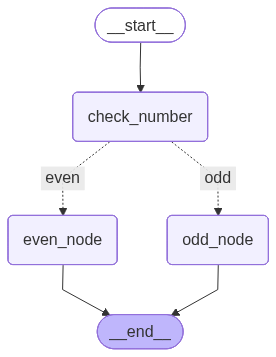

In [3]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())